## Types of similarity search
1. Cosine Similarity
2. Euclidean Distance
3. Dot Product

## 1. Cosine Similarity
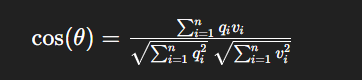

- Here v = stored embeddings
- q = input query used 
> Numerator performs the element wise mutliplication and denominator performs the mulitplication of magnitude of q and v

In [6]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2') # 384 dimensional embeddings model

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1335.53it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
sample_embeddings = model.encode("Hello world")
print("length of embedding vector:", len(sample_embeddings))

length of embedding vector: 384


In [11]:
stored_emdbeddings = [
    model.encode("Paris is the capital of France."),
    model.encode("Berlin is the capital of Germany."),
    model.encode("Madrid is the capital of Spain.")
]

In [12]:
query = "What is the capital of France?"
query_emb = model.encode(query)

from sklearn.metrics.pairwise import cosine_similarity
similarities = cosine_similarity([query_emb], stored_emdbeddings)
print("Similarity scores:", similarities)

Similarity scores: [[0.8560699 0.4033602 0.4169125]]


In [14]:
import numpy as np
import math

def cosine_similarity_manual(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    mag_vec1 = sum([el ** 2 for el in vec1]) ** 0.5
    mag_vec2 = sum([el ** 2 for el in vec2]) ** 0.5
    if mag_vec1 == 0 or mag_vec2 == 0:
        return 0.0
    return dot_product / (mag_vec1 * mag_vec2)

result = cosine_similarity_manual(query_emb, stored_emdbeddings[2])
result

np.float32(0.41691256)

## 2. Euclidean Distance
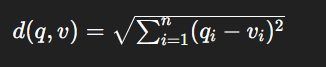

In [16]:
def euclidean_distance(vec1, vec2):
    distance = math.sqrt(sum([(a - b) ** 2 for a, b in zip(vec1, vec2)]))
    return distance

[euclidean_distance(query_emb, stored_emdbeddings[i]) for i in range(len(stored_emdbeddings))]

[0.536526255952579, 1.0923735540615944, 1.0798957215405338]

In [17]:
# import euclidean distance

[math.dist(query_emb, stored_emdbeddings[i]) for i in range(len(stored_emdbeddings))]

[0.5365263330317426, 1.0923734794354816, 1.0798958646455925]

## 3. Dot Product

In [22]:

[np.dot(query_emb, stored_emdbeddings[i]) for i in range(len(stored_emdbeddings))]

[np.float32(0.85606986), np.float32(0.40336013), np.float32(0.41691256)]